In [1]:
!git clone https://github.com/karolpiczak/ESC-50.git

Cloning into 'ESC-50'...
remote: Enumerating objects: 4199, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 4199 (delta 62), reused 34 (delta 34), pack-reused 4130 (from 1)
Receiving objects: 100% (4199/4199), 878.77 MiB | 28.67 MiB/s, done.
Resolving deltas: 100% (292/292), done.
Updating files: 100% (2011/2011), done.


In [2]:
import librosa
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
from tqdm import tqdm # Biblioteca para mostrar uma barra de progresso
warnings.filterwarnings('ignore')

### 1. Upload do Dataset

Aqui definimos parâmetros como a taxa de amostragem sendo 16kHz e a extração de 40 características acústicas (MFCCs).

Definimos que as categorias 0 a 24 seriam o som padrão do ambiente, enquanto as categorias 40 a 49 seriam as anomalias.

Dividimos os sons normais em 80% para treino e 20% para teste, enquanto 100% dos sons anômalos são reservados para teste, isso porque o sistema aprende apenas o que é "normal".

In [3]:
caminho_csv = 'ESC-50/meta/esc50.csv'
pasta_audio = 'ESC-50/audio/'

In [4]:
TAXA_AMOSTRAGEM = 16000
N_MFCC = 40

In [5]:
df = pd.read_csv(caminho_csv)

In [6]:
# ==========================================
# 1. SEPARAÇÃO DOS ÁUDIOS
# ==========================================

# Normal: classes 0 a 24
df_normal = df[df['target'] <= 24].copy()

# Anomalia: classes 40 a 49
df_anomalia = df[df['target'] >= 40].copy()

# Divisão por ÁUDIO, antes da extração dos frames
df_treino_normal, df_teste_normal = train_test_split(
    df_normal,
    test_size=0.20,
    random_state=42
)

print("=== DIVISÃO DOS ÁUDIOS ===")
print(f"Áudios normais para treino: {len(df_treino_normal)}")
print(f"Áudios normais para teste: {len(df_teste_normal)}")
print(f"Áudios anômalos para teste: {len(df_anomalia)}")

=== DIVISÃO DOS ÁUDIOS ===
Áudios normais para treino: 800
Áudios normais para teste: 200
Áudios anômalos para teste: 400


### 2. Processamento e Análise Exploratória

Aqui convertemos os arquivos de áudio bruto em matrizes matemáticas.
Primeiro convertemos cada áudio para canal único (mono), aplicamos a taxa de amostragem como 16kHz, e extraímos os 40 Coeficientes Cepstrais de Frequência Mel (MFCCs): divide o áudio em frames e mapeia as frequências de forma semelhante a como o ouvido humano percebe o som.
Além disso, é calculado delta (derivada de 1 ordem) que mede a velocidade com que as características do som mudam, e delta-delta (derivada de 2 ordem) que calcula a aceleração das mudanças.
As três matrizes (MFCC, Delta e Delta-Delta) são empilhadas, resultando em 120 características por frame, sendo cada característica 1 coluna e cada frame 1 linha.

In [7]:
# ==========================================
# 2. EXTRAÇÃO DOS MFCCs por áudio
# ==========================================

def extrair_mfcc_por_audio(df_audios):

    dados_audios = []

    for index, row in tqdm(
        df_audios.iterrows(),
        total=len(df_audios)
    ):

        caminho_completo = os.path.join(
            pasta_audio,
            row['filename']
        )

        # 1. Carregamento e padronização
        y, sr = librosa.load(
            caminho_completo,
            sr=TAXA_AMOSTRAGEM,
            mono=True
        )

        # 2. MFCC
        mfccs = librosa.feature.mfcc(
            y=y,
            sr=sr,
            n_mfcc=N_MFCC
        )

        # 3. Delta
        mfcc_delta = librosa.feature.delta(mfccs)

        # 4. Delta-Delta
        mfcc_delta2 = librosa.feature.delta(
            mfccs,
            order=2
        )

        # 5. Combina as características
        mfccs_combinados = np.vstack(
            (mfccs, mfcc_delta, mfcc_delta2)
        )

        # 6. Transpõe:
        #    linhas = frames
        #    colunas = features
        frames = mfccs_combinados.T

        # Guarda o áudio inteiro como uma unidade
        dados_audios.append({
            'filename': row['filename'],
            'target': row['target'],
            'classe': row['category'],
            'frames': frames
        })

    return dados_audios

Aqui realizamos a partição do dataset para alimentar os algoritmos não supervisionados e supervisionados

In [8]:
# ==========================================
# DIVISÃO DOS ÁUDIOS
# ==========================================

# ------------------------------------------
# 1. SEPARAÇÃO DAS CLASSES
# ------------------------------------------

# Normais: classes 0 a 24
df_normal = df[
    df['target'] <= 24
].copy()

# Anomalias: classes 40 a 49
df_anomalia = df[
    df['target'] >= 40
].copy()


# ------------------------------------------
# 2. DIVISÃO DOS ÁUDIOS NORMAIS
# ------------------------------------------

# 80% para treino
# 20% para teste

df_treino_normal, df_teste_normal = train_test_split(
    df_normal,
    test_size=0.20,
    random_state=42
)


# ------------------------------------------
# 3. DIVISÃO DOS ÁUDIOS ANÔMALOS
# ------------------------------------------

# Classes 40 a 44: Anomalias para treino do Naive Bayes (ex: sirene, choro, etc.)
df_treino_anomalia = df[
    (df['target'] >= 40) & (df['target'] <= 44)
].copy()

# Classes 45 a 49: Anomalias inéditas para o teste final de todos os modelos
df_teste_anomalia = df[
    (df['target'] >= 45) & (df['target'] <= 49)
].copy()


# ------------------------------------------
# 4. INFORMAÇÕES DA DIVISÃO
# ------------------------------------------

print("=== DIVISÃO DOS ÁUDIOS ===")

print(
    f"Áudios normais para treino: "
    f"{len(df_treino_normal)}"
)

print(
    f"Áudios normais para teste: "
    f"{len(df_teste_normal)}"
)

print(
    f"Áudios anômalos para treino (NB): "
    f"{len(df_treino_anomalia)}"
)

print(
    f"Áudios anômalos para teste: "
    f"{len(df_teste_anomalia)}"
)


# ------------------------------------------
# 5. EXTRAÇÃO DOS MFCCs
# ------------------------------------------

print("\nExtraindo MFCCs dos áudios de TREINO NORMAL...")

audios_treino = extrair_mfcc_por_audio(
    df_treino_normal
)


print("\nExtraindo MFCCs dos áudios ANÔMALOS DE TREINO...")

audios_treino_anomalia = extrair_mfcc_por_audio(
    df_treino_anomalia
)


print("\nExtraindo MFCCs dos áudios NORMAIS DE TESTE...")

audios_teste_normal = extrair_mfcc_por_audio(
    df_teste_normal
)


print("\nExtraindo MFCCs dos áudios ANÔMALOS DE TESTE...")

audios_teste_anomalia = extrair_mfcc_por_audio(
    df_teste_anomalia
)

=== DIVISÃO DOS ÁUDIOS ===
Áudios normais para treino: 800
Áudios normais para teste: 200
Áudios anômalos para treino (NB): 200
Áudios anômalos para teste: 200

Extraindo MFCCs dos áudios de TREINO NORMAL...


100%|██████████| 800/800 [00:25<00:00, 31.90it/s]



Extraindo MFCCs dos áudios ANÔMALOS DE TREINO...


100%|██████████| 200/200 [00:02<00:00, 85.84it/s]



Extraindo MFCCs dos áudios NORMAIS DE TESTE...


100%|██████████| 200/200 [00:02<00:00, 85.10it/s]



Extraindo MFCCs dos áudios ANÔMALOS DE TESTE...


100%|██████████| 200/200 [00:02<00:00, 84.22it/s]


Para cada áudio, pegamos a matriz e calculamos a média e desvio padrão. Concatenamos a média e desvio padrão, formando um único vetor de 240 posições. Aplicamos isso nos conjuntos de treino e teste, resultando em matrizes de (n_audios, 240)

In [9]:
# ==========================================
# PREPARAÇÃO DOS DADOS PARA O GMM E KDE
# ==========================================

def agregar_estatisticas_audios(audios):

    dados = []

    for audio in audios:

        frames = audio['frames']

        # Média de cada coeficiente MFCC ao longo dos frames
        media = np.mean(frames, axis=0)

        # Desvio padrão de cada coeficiente MFCC
        desvio_padrao = np.std(frames, axis=0)

        # Concatena média + desvio padrão
        vetor = np.concatenate([
            media,
            desvio_padrao
        ])

        dados.append(vetor)

    return np.array(dados)


# ------------------------------------------
# DADOS DE TREINO
# ------------------------------------------

X_treino = agregar_estatisticas_audios(
    audios_treino
)

# ------------------------------------------
# DADOS DE TESTE
# ------------------------------------------

X_teste_normal = agregar_estatisticas_audios(
    audios_teste_normal
)

X_teste_anomalia = agregar_estatisticas_audios(
    audios_teste_anomalia
)

# ------------------------------------------
# DADOS DE ANOMALIAS PARA TREINAMENTO DO NB
# ------------------------------------------

X_treino_anomalia_nb = agregar_estatisticas_audios(
    audios_treino_anomalia
)

print(f"Dados de treino: {X_treino.shape}")
print(f"Dados normais de teste: {X_teste_normal.shape}")
print(f"Dados anômalos de teste: {X_teste_anomalia.shape}")
print(f"Dados anômalos de treino (NB): {X_treino_anomalia_nb.shape}")

Dados de treino: (800, 240)
Dados normais de teste: (200, 240)
Dados anômalos de teste: (200, 240)
Dados anômalos de treino (NB): (200, 240)


Aqui normalizamos os dados com StandardScaler e aplicamos PCA para condensar e manter 90% de toda a informação.

In [10]:
# ==========================================
# NORMALIZAÇÃO + PCA
# ==========================================

from sklearn.decomposition import PCA

# ------------------------------------------
# STANDARD SCALER
# ------------------------------------------

scaler = StandardScaler()

# Aprende SOMENTE com os áudios normais de treino
X_treino = scaler.fit_transform(
    X_treino
)

# Aplica o mesmo scaler aos demais conjuntos
X_treino_anomalia_nb = scaler.transform(
    X_treino_anomalia_nb
)

X_teste_normal = scaler.transform(
    X_teste_normal
)

X_teste_anomalia = scaler.transform(
    X_teste_anomalia
)


# ------------------------------------------
# PCA
# ------------------------------------------

pca = PCA(
    n_components=0.90,
    random_state=42
)

# PCA aprende SOMENTE com os áudios normais de treino
X_treino_pca = pca.fit_transform(
    X_treino
)

# Aplica o mesmo PCA aos demais conjuntos
X_treino_anomalia_nb_pca = pca.transform(
    X_treino_anomalia_nb
)

X_teste_normal_pca = pca.transform(
    X_teste_normal
)

X_teste_anomalias_pca = pca.transform(
    X_teste_anomalia
)


# ------------------------------------------
# VERIFICAÇÃO
# ------------------------------------------

print(
    f"Treino normal após PCA: "
    f"{X_treino_pca.shape}"
)

print(
    f"Treino anomalia NB após PCA: "
    f"{X_treino_anomalia_nb_pca.shape}"
)

print(
    f"Teste normal após PCA: "
    f"{X_teste_normal_pca.shape}"
)

print(
    f"Teste anomalia após PCA: "
    f"{X_teste_anomalias_pca.shape}"
)

print(
    f"Variância explicada pelo PCA: "
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

Treino normal após PCA: (800, 93)
Treino anomalia NB após PCA: (200, 93)
Teste normal após PCA: (200, 93)
Teste anomalia após PCA: (200, 93)
Variância explicada pelo PCA: 90.22%


Aqui unificamos os audios normais e anomalos de teste, e definimos 0 como audios normais e 1 para anomalos.

In [11]:
# ==========================================
# 4. CONJUNTO DE TESTE FINAL
# ==========================================

X_teste = np.vstack([
    X_teste_normal_pca,
    X_teste_anomalias_pca
])

y_teste = np.concatenate([
    np.zeros(len(X_teste_normal_pca)),
    np.ones(len(X_teste_anomalias_pca))
])


print("\n=== DIVISÃO CONCLUÍDA ===")
print(f"Áudios de treino: {len(X_treino_pca)}")
print(f"Áudios normais de teste: {len(X_teste_normal_pca)}")
print(f"Áudios anômalos de teste: {len(X_teste_anomalias_pca)}")
print(f"Áudios totais de teste: {len(X_teste)}")
print(f"Features utilizadas pelos modelos: {X_treino_pca.shape[1]}")


=== DIVISÃO CONCLUÍDA ===
Áudios de treino: 800
Áudios normais de teste: 200
Áudios anômalos de teste: 200
Áudios totais de teste: 400
Features utilizadas pelos modelos: 93


### 3. Análise de Dados

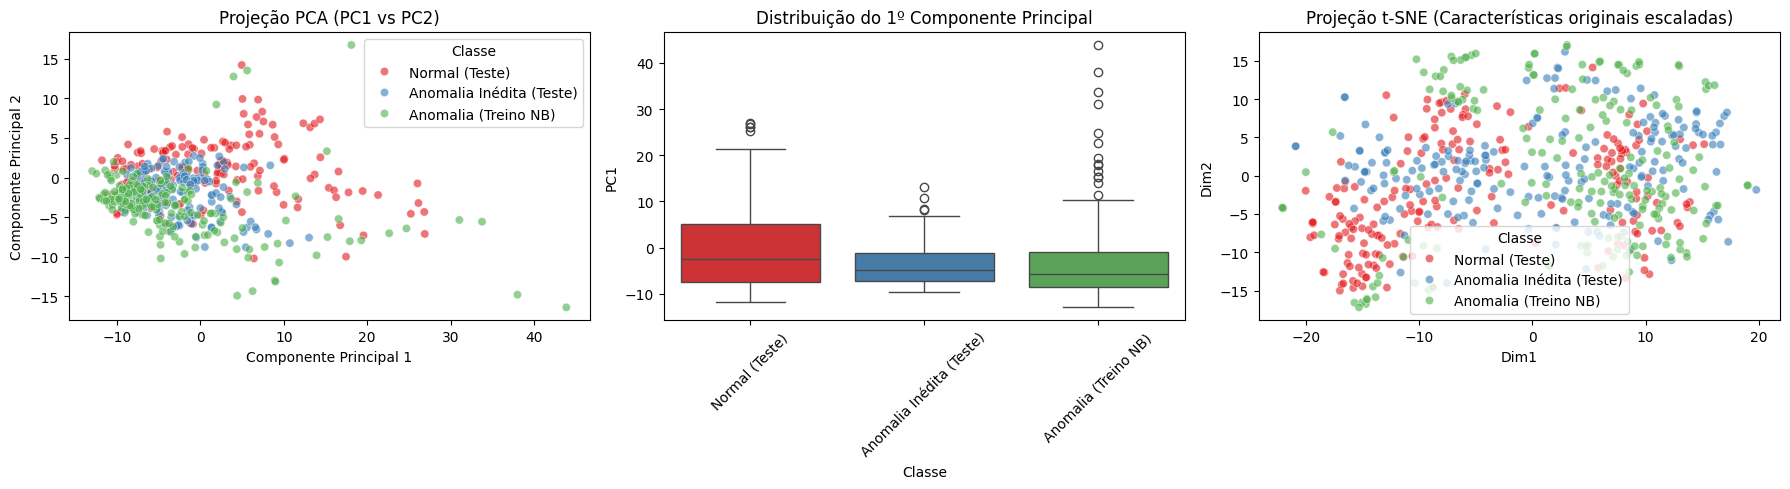

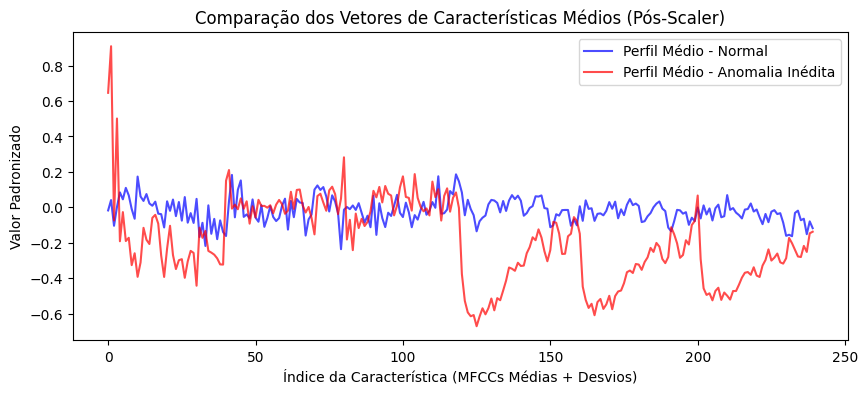

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np

# 1. Preparar um DataFrame consolidado com todos os dados de teste e treino anômalo
# Usaremos os dados APÓS o Scaler, mas ANTES do PCA para o t-SNE, e os do PCA para os boxplots
X_tudo = np.vstack([X_teste_normal, X_teste_anomalia, X_treino_anomalia_nb])
X_tudo_pca = np.vstack([X_teste_normal_pca, X_teste_anomalias_pca, X_treino_anomalia_nb_pca])

labels = (
    ['Normal (Teste)'] * len(X_teste_normal) +
    ['Anomalia Inédita (Teste)'] * len(X_teste_anomalia) +
    ['Anomalia (Treino NB)'] * len(X_treino_anomalia_nb)
)

df_vis = pd.DataFrame(X_tudo_pca[:, :5], columns=[f'PC{i+1}' for i in range(5)]) # Pegando apenas os 5 primeiros PCs
df_vis['Classe'] = labels

plt.figure(figsize=(18, 5))

# --- GRÁFICO 1: Scatter plot dos 2 primeiros Componentes Principais (PCA) ---
plt.subplot(1, 3, 1)
sns.scatterplot(data=df_vis, x='PC1', y='PC2', hue='Classe', alpha=0.6, palette='Set1')
plt.title('Projeção PCA (PC1 vs PC2)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# --- GRÁFICO 2: Distribuição do PC1 (Boxplot) ---
# Ajuda a ver se algum componente principal conseguiu separar as anomalias
plt.subplot(1, 3, 2)
sns.boxplot(data=df_vis, x='Classe', y='PC1', palette='Set1')
plt.title('Distribuição do 1º Componente Principal')
plt.xticks(rotation=45)

# --- GRÁFICO 3: Projeção t-SNE (Baseado nos dados escalados, não PCA) ---
plt.subplot(1, 3, 3)
# t-SNE é excelente para achar clusters locais em alta dimensionalidade
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_tudo)
df_tsne = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])
df_tsne['Classe'] = labels

sns.scatterplot(data=df_tsne, x='Dim1', y='Dim2', hue='Classe', alpha=0.6, palette='Set1')
plt.title('Projeção t-SNE (Características originais escaladas)')

plt.tight_layout()
plt.show()

# --- GRÁFICO 4: Correlação entre as classes e as médias dos MFCCs ---
# Analisar se a média pura dos vetores normais e anômalos difere
media_normal = np.mean(X_teste_normal, axis=0)
media_anomala = np.mean(X_teste_anomalia, axis=0)

plt.figure(figsize=(10, 4))
plt.plot(media_normal, label='Perfil Médio - Normal', color='blue', alpha=0.7)
plt.plot(media_anomala, label='Perfil Médio - Anomalia Inédita', color='red', alpha=0.7)
plt.title('Comparação dos Vetores de Características Médios (Pós-Scaler)')
plt.xlabel('Índice da Característica (MFCCs Médias + Desvios)')
plt.ylabel('Valor Padronizado')
plt.legend()
plt.show()

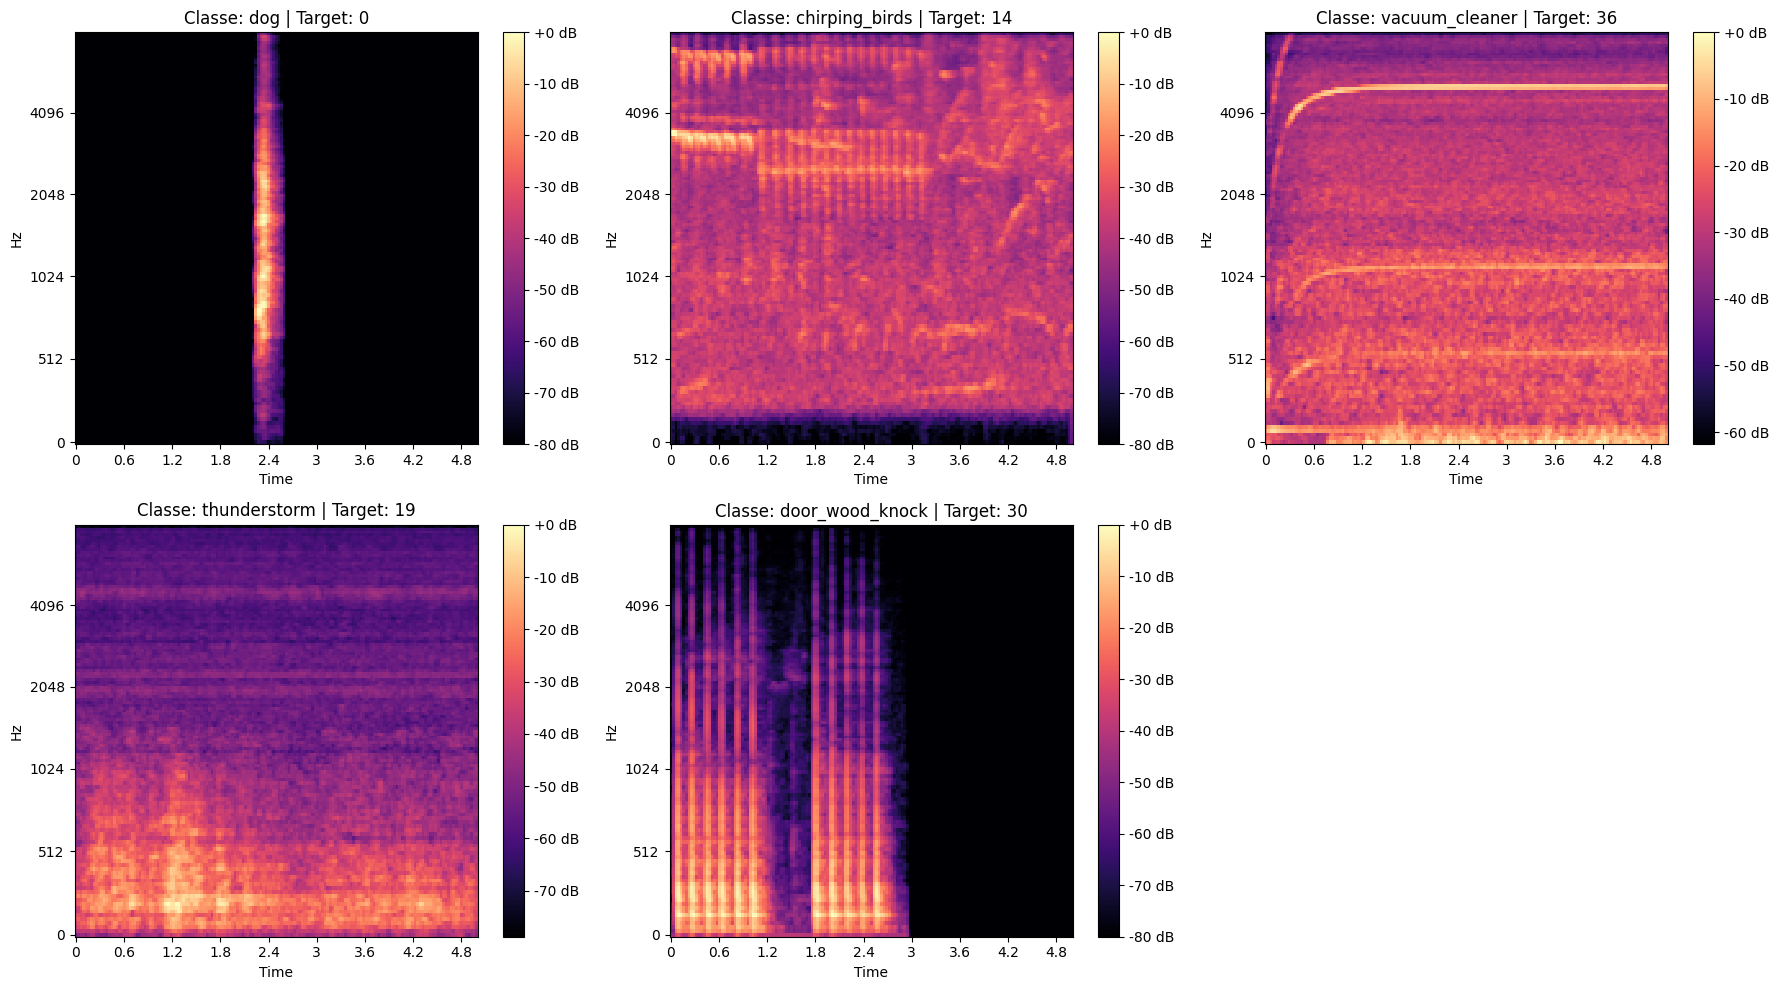

In [13]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

# Seleciona 5 classes únicas (pode ser da coluna 'category' ou 'target')
classes_exemplo = df['category'].unique()[:5]

plt.figure(figsize=(18, 10))

for i, classe in enumerate(classes_exemplo):
    # Pega o primeiro arquivo correspondente à classe
    amostra = df[df['category'] == classe].iloc[0]
    caminho_audio = os.path.join(pasta_audio, amostra['filename'])

    # Carrega o áudio
    y, sr = librosa.load(caminho_audio, sr=TAXA_AMOSTRAGEM, mono=True)

    # Extrai o Espectrograma de Mel (mais próximo da percepção humana)
    espectrograma = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    espectrograma_db = librosa.power_to_db(espectrograma, ref=np.max)

    # Plota
    plt.subplot(2, 3, i + 1)
    librosa.display.specshow(
        espectrograma_db,
        sr=sr,
        x_axis='time',
        y_axis='mel',
        cmap='magma'
    )
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Classe: {classe} | Target: {amostra['target']}")

plt.tight_layout()
plt.show()

### 4. Implementação dos Modelos Não-Supervisionados (GMM/KDE)

In [54]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

Executa um loop testando o GMM com 1 até 20 componentes para encontrar a estrutura de distribuição dos áudios normais, avaliando cada um com métricas estatísticas AIC e BIC que evitam overfitting. Plota as curvas, seleciona o melhor numero de componentes e treina o gmm definitivo com base nisso.


--- Otimizando GMM (Buscando melhor número de componentes) ---


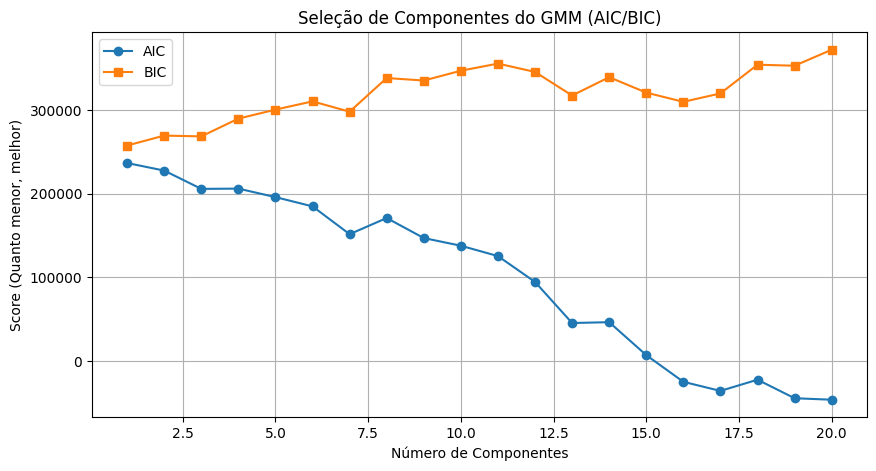

Melhor número de componentes encontrado para o GMM: 1
GMM definitivo treinado com sucesso.


In [55]:
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# ==========================================
# 1. OTIMIZAÇÃO DO GMM (AIC / BIC)
# ==========================================

print("\n--- Otimizando GMM (Buscando melhor número de componentes) ---")

n_components_range = range(1, 21)

aic_scores = []
bic_scores = []

# ------------------------------------------
# Testando de 1 a 20 componentes
# ------------------------------------------

for n in n_components_range:

    gmm_temp = GaussianMixture(
        n_components=n,
        covariance_type='full',
        random_state=42
    )

    gmm_temp.fit(X_treino_pca)

    aic_scores.append(
        gmm_temp.aic(X_treino_pca)
    )

    bic_scores.append(
        gmm_temp.bic(X_treino_pca)
    )


# ------------------------------------------
# Gráfico de AIC e BIC
# ------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    n_components_range,
    aic_scores,
    label='AIC',
    marker='o'
)

plt.plot(
    n_components_range,
    bic_scores,
    label='BIC',
    marker='s'
)

plt.xlabel('Número de Componentes')
plt.ylabel('Score (Quanto menor, melhor)')
plt.title('Seleção de Componentes do GMM (AIC/BIC)')

plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------
# Selecionando pelo menor BIC
# ------------------------------------------

melhor_n_gmm = n_components_range[
    np.argmin(bic_scores)
]

print(
    f"Melhor número de componentes encontrado "
    f"para o GMM: {melhor_n_gmm}"
)


# ------------------------------------------
# Treinando o GMM definitivo
# ------------------------------------------

gmm = GaussianMixture(
    n_components=melhor_n_gmm,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_treino_pca)

print("GMM definitivo treinado com sucesso.")

Aqui encontramos a melhor bandwidth para o KDE, testando 7 valores distribuídos em uma escala logarítmica (entre 0.1 e 10) utilizando GridSearchCV com 3 dobras (3-fold-cross-validation).

In [56]:
# ==========================================
# 2. OTIMIZAÇÃO E TREINAMENTO DO KDE
# ==========================================
from sklearn.utils import resample

print("\n--- Otimizando KDE no espaço PCA ---")

print(
    f"Dados utilizados pelo KDE: {X_treino_pca.shape}"
)


# ------------------------------------------
# 1. AMOSTRAGEM PARA GRIDSEARCH
# ------------------------------------------

# Como agora temos apenas um vetor por áudio,
# usamos uma amostra dos próprios áudios.

n_amostras_grid = min(
    500,
    len(X_treino_pca)
)

X_treino_grid = resample(
    X_treino_pca,
    n_samples=n_amostras_grid,
    random_state=42
)


# ------------------------------------------
# 2. VALORES DE BANDWIDTH TESTADOS
# ------------------------------------------

params = {
    'bandwidth': np.logspace(-1, 1, 7)
}


# ------------------------------------------
# 3. GRIDSEARCH
# ------------------------------------------

grid = GridSearchCV(
    KernelDensity(
        kernel='gaussian',
        rtol=1e-2
    ),
    params,
    cv=3,
    n_jobs=-1
)

grid.fit(X_treino_grid)


# ------------------------------------------
# 4. MELHOR BANDWIDTH
# ------------------------------------------

melhor_bw = grid.best_estimator_.bandwidth

print(
    f"Melhor bandwidth encontrado para o KDE: "
    f"{melhor_bw:.4f}"
)


# ------------------------------------------
# 5. KDE DEFINITIVO
# ------------------------------------------

kde = KernelDensity(
    kernel='gaussian',
    bandwidth=melhor_bw,
    rtol=1e-2
)

# Treina usando TODOS os áudios de treino
kde.fit(X_treino_pca)


print("KDE definitivo treinado com sucesso!")


--- Otimizando KDE no espaço PCA ---
Dados utilizados pelo KDE: (800, 93)
Melhor bandwidth encontrado para o KDE: 1.0000
KDE definitivo treinado com sucesso!


Aqui avaliamos a capacidade do GMM identificar anomalias, otimiza o threshold e visualiza a performance por meio da curva ROC.
Para isso, obtem o log-likehood (verosimilhança) das amostras, mapeia taxa de acerto (TPR) contra a taxa de alarmes falsos (FPR). Encontra o ponto na curva ROC que maximiza a diferença entre TPR e FPR. Aplica o limiar encontrado para fazer os rótulos finais.

AVALIAÇÃO GMM (SEM DATA LEAKAGE)
Limiar (Percentil 95% do treino): 210.521676
Acurácia final no Teste: 50.00%
AUC ROC: 0.4467


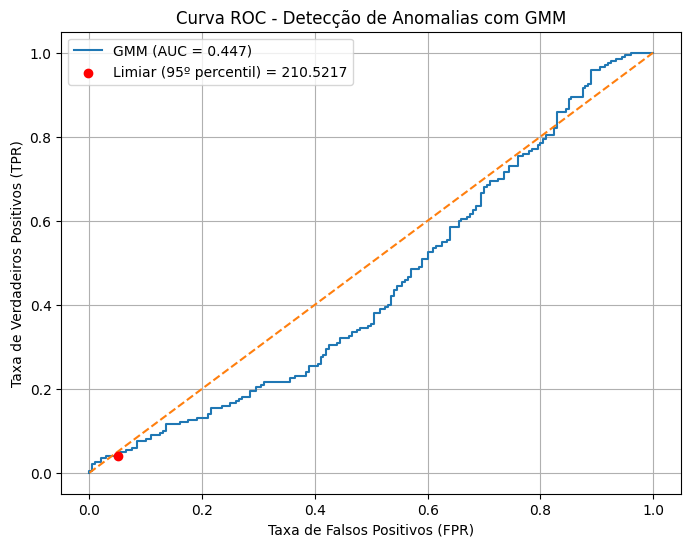

In [57]:
# 1. Definir o limiar usando APENAS os dados de TREINO
scores_treino_gmm = -gmm.score_samples(X_treino_pca)
percentil_corte = 95
melhor_threshold_gmm = np.percentile(scores_treino_gmm, percentil_corte)

# 2. Calcular o score de anomalia no TESTE
score_anomalia_gmm = -gmm.score_samples(X_teste)

# 3. Gerar previsões e métricas no TESTE
pred_gmm = (score_anomalia_gmm >= melhor_threshold_gmm).astype(int)
acuracia_gmm = accuracy_score(y_teste, pred_gmm) * 100

# 4. Curva ROC e AUC calculadas no TESTE
fpr, tpr, thresholds = roc_curve(y_teste, score_anomalia_gmm)
roc_auc = auc(fpr, tpr)

# Encontra a posição no gráfico onde o nosso limiar de percentil se encaixa
indice_threshold = np.argmin(np.abs(thresholds - melhor_threshold_gmm))

print("=" * 50)
print("AVALIAÇÃO GMM (SEM DATA LEAKAGE)")
print("=" * 50)
print(f"Limiar (Percentil {percentil_corte}% do treino): {melhor_threshold_gmm:.6f}")
print(f"Acurácia final no Teste: {acuracia_gmm:.2f}%")
print(f"AUC ROC: {roc_auc:.4f}")

# 5. Plotando a Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'GMM (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.scatter(
    fpr[indice_threshold],
    tpr[indice_threshold],
    color='red',
    zorder=5,
    label=f'Limiar ({percentil_corte}º percentil) = {melhor_threshold_gmm:.4f}'
)

plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Detecção de Anomalias com GMM')
plt.legend()
plt.grid(True)
plt.show()

Calcula as pontuações de anomalia, une os conjuntos de teste e avalia o desempenho com a curva roc

In [58]:
# ------------------------------------------
# 1. LIMIAR COM DADOS DE TREINO (PERCENTIL)
# ------------------------------------------

scores_treino_kde = -kde.score_samples(X_treino_pca)
percentil_corte = 95
melhor_threshold_kde = np.percentile(scores_treino_kde, percentil_corte)


# ------------------------------------------
# 2. AVALIAÇÃO NO CONJUNTO DE TESTE UNIFICADO
# ------------------------------------------

# Calcula scores de anomalia diretamente no X_teste global
score_anomalia_kde = -kde.score_samples(X_teste)

# Previsões usando o limiar calibrado no treino
pred_kde = (score_anomalia_kde >= melhor_threshold_kde).astype(int)
acuracia_kde = accuracy_score(y_teste, pred_kde) * 100

# Curva ROC e AUC no teste
fpr_kde, tpr_kde, _ = roc_curve(y_teste, score_anomalia_kde)
roc_auc_kde = auc(fpr_kde, tpr_kde)


# ------------------------------------------
# 3. RESULTADOS
# ------------------------------------------

print("\n" + "=" * 50)
print("RESULTADOS KDE (SEM DATA LEAKAGE)")
print("=" * 50)
print(f"Limiar (Percentil {percentil_corte}% do treino): {melhor_threshold_kde:.6f}")
print(f"AUC ROC: {roc_auc_kde:.4f}")
print(f"Acurácia: {acuracia_kde:.2f}%")


RESULTADOS KDE (SEM DATA LEAKAGE)
Limiar (Percentil 95% do treino): 92.145895
AUC ROC: 0.4674
Acurácia: 50.00%


### 5. Implementação de Modelos Supervisionados (Naive Bayes)

In [59]:
print("X_treino:", X_treino.shape)
print("X_treino_anomalia_nb:", X_treino_anomalia_nb.shape)
print("X_teste_normal:", X_teste_normal.shape)
print("X_teste_anomalia:", X_teste_anomalia.shape)

X_treino: (800, 240)
X_treino_anomalia_nb: (200, 240)
X_teste_normal: (200, 240)
X_teste_anomalia: (200, 240)


In [60]:
# ==========================================
# 1. CRIANDO A BASE SUPERVISIONADA (COM PCA)
# ==========================================

# Treino: 800 normais + 200 anômalos (PCA)
X_treino_nb = np.vstack([
    X_treino_pca,
    X_treino_anomalia_nb_pca
])

y_treino_nb = np.concatenate([
    np.zeros(len(X_treino_pca)),
    np.ones(len(X_treino_anomalia_nb_pca))
])


# ==========================================
# 2. PIPELINE E OTIMIZAÇÃO DO NAIVE BAYES
# ==========================================

pipeline_nb = Pipeline([
    ('nb', GaussianNB())
])

param_grid_nb = {
    'nb__var_smoothing': np.logspace(-12, 0, 13)
}

grid_nb = GridSearchCV(
    pipeline_nb,
    param_grid_nb,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1
)

grid_nb.fit(X_treino_nb, y_treino_nb)


# ==========================================
# 3. RESULTADOS DA OTIMIZAÇÃO
# ==========================================

print("=" * 50)
print("NAIVE BAYES - RESULTADOS DO TREINO")
print("=" * 50)

print(f"Melhor var_smoothing: {grid_nb.best_params_['nb__var_smoothing']:.12f}")
print(f"Melhor Balanced Accuracy (Validação Cruzada): {grid_nb.best_score_ * 100:.2f}%")


# ==========================================
# 4. PREDIÇÃO NO TESTE GLOBAL (X_teste / y_teste)
# ==========================================

nb = grid_nb.best_estimator_

# Usa as matrizes globais de teste já unificadas nas células anteriores
pred_nb = nb.predict(X_teste)
acuracia_nb = accuracy_score(y_teste, pred_nb) * 100

# Probabilidade para calcular ROC/AUC
prob_nb = nb.predict_proba(X_teste)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_teste, prob_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)

print("\n" + "=" * 50)
print("NAIVE BAYES - RESULTADOS DO TESTE")
print("=" * 50)
print(f"Acurácia no conjunto de teste: {acuracia_nb:.2f}%")
print(f"AUC ROC no conjunto de teste: {roc_auc_nb:.4f}")

NAIVE BAYES - RESULTADOS DO TREINO
Melhor var_smoothing: 0.001000000000
Melhor Balanced Accuracy (Validação Cruzada): 62.44%

NAIVE BAYES - RESULTADOS DO TESTE
Acurácia no conjunto de teste: 51.00%
AUC ROC no conjunto de teste: 0.5598


RESULTADOS NAIVE BAYES (SEM DATA LEAKAGE)
Limiar otimizado no Treino (CV): 0.036625
AUC ROC no Teste: 0.5598
Acurácia com threshold otimizado: 52.50%


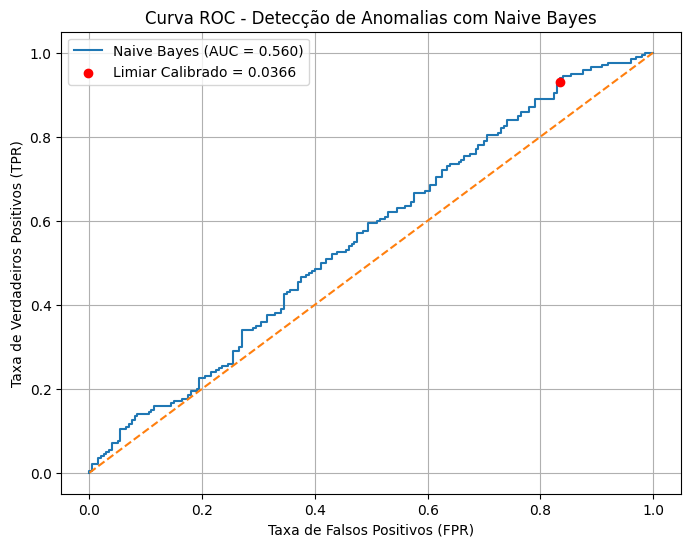

In [61]:
from sklearn.model_selection import cross_val_predict

# ------------------------------------------
# 1. OTIMIZAÇÃO DO LIMIAR VIA VALIDAÇÃO CRUZADA (NO TREINO)
# ------------------------------------------

# Obtém as probabilidades de treino de forma honesta (Out-of-Fold)
prob_treino_nb = cross_val_predict(
    nb, X_treino_nb, y_treino_nb, cv=5, method='predict_proba'
)[:, 1]

# Calcula a curva ROC apenas nos dados de treino
fpr_tr, tpr_tr, thresholds_tr = roc_curve(y_treino_nb, prob_treino_nb)
j_scores_tr = tpr_tr - fpr_tr
melhor_threshold_nb = thresholds_tr[np.argmax(j_scores_tr)]


# ------------------------------------------
# 2. AVALIAÇÃO IMPARCIAL NO TESTE GLOBAL
# ------------------------------------------

# Probabilidade do teste global
proba_anomalia_nb = nb.predict_proba(X_teste)[:, 1]

# Previsões usando o limiar calibrado no treino
pred_nb_roc = (proba_anomalia_nb >= melhor_threshold_nb).astype(int)

# Métricas no conjunto de teste
acuracia_nb_roc = accuracy_score(y_teste, pred_nb_roc) * 100
fpr_nb, tpr_nb, _ = roc_curve(y_teste, proba_anomalia_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)

# Ponto para o gráfico no teste
indice_grafico = np.argmin(np.abs(fpr_nb - fpr_nb[np.argmax(tpr_nb - fpr_nb)]))

print("=" * 50)
print("RESULTADOS NAIVE BAYES (SEM DATA LEAKAGE)")
print("=" * 50)
print(f"Limiar otimizado no Treino (CV): {melhor_threshold_nb:.6f}")
print(f"AUC ROC no Teste: {roc_auc_nb:.4f}")
print(f"Acurácia com threshold otimizado: {acuracia_nb_roc:.2f}%")


# ------------------------------------------
# 3. GRÁFICO ROC
# ------------------------------------------

plt.figure(figsize=(8, 6))
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {roc_auc_nb:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.scatter(
    fpr_nb[indice_grafico],
    tpr_nb[indice_grafico],
    color='red',
    zorder=5,
    label=f'Limiar Calibrado = {melhor_threshold_nb:.4f}'
)

plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Detecção de Anomalias com Naive Bayes')
plt.legend()
plt.grid(True)
plt.show()

### 6. Avaliação de Desempenho